# 🏥 Insurance Dataset — Comprehensive Exploratory Data Analysis

**Dataset:** Medical Cost Personal Dataset  
**Goal:** Understand the key factors that drive insurance charges and uncover hidden patterns in the data.

### Table of Contents
1. [Setup & Data Loading](#1)
2. [Dataset Overview](#2)
3. [Missing Values & Data Quality](#3)
4. [Univariate Analysis](#4)
5. [Bivariate Analysis](#5)
6. [Multivariate Analysis](#6)
7. [Feature Relationships with Target (Charges)](#7)
8. [Outlier Detection](#8)
9. [Statistical Summary & Key Insights](#9)
10. [Model Building (from Insurance.ipynb)](#10)

## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# ── Aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.titlesize': 16,
})
PALETTE = {'no': '#4C72B0', 'yes': '#DD8452'}   # smoker colour map
REGION_PALETTE = sns.color_palette('Set2', 4)
print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
df = pd.read_csv(r'C:\Users\Mayank Joshi\Downloads\insurance[1].csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (1338, 7)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


## 2. Dataset Overview

In [3]:
print('=== dtypes & non-null counts ===')
df.info()
print()
print('=== Descriptive Statistics ===')
df.describe(include='all').round(2)

=== dtypes & non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB

=== Descriptive Statistics ===


,age,sex,bmi,children,smoker,region,charges
count,1338.00,1338,1338.00,1338.00,1338,1338,1338.00
unique,NaN,2,NaN,NaN,2,4,NaN
top,NaN,male,NaN,NaN,no,southeast,NaN
freq,NaN,676,NaN,NaN,1064,364,NaN
mean,39.21,NaN,30.66,1.09,NaN,NaN,13270.42
std,14.05,NaN,6.10,1.21,NaN,NaN,12110.01
min,18.00,NaN,15.96,0.00,NaN,NaN,1121.87
25%,27.00,NaN,26.30,0.00,NaN,NaN,4740.29
50%,39.00,NaN,30.40,1.00,NaN,NaN,9382.03
75%,51.00,NaN,34.69,2.00,NaN,NaN,16639.91


In [4]:
cat_cols = ['sex', 'smoker', 'region']
for col in cat_cols:
    print(f'\n── {col.upper()} ──')
    counts = df[col].value_counts()
    pct    = df[col].value_counts(normalize=True) * 100
    print(pd.concat([counts, pct.round(1)], axis=1, keys=['Count', '%']))


── SEX ──
        Count     %
sex                
male      676  50.5
female    662  49.5

── SMOKER ──
        Count     %
smoker             
no       1064  79.5
yes       274  20.5

── REGION ──
           Count     %
region                
southeast    364  27.2
southwest    325  24.3
northwest    325  24.3
northeast    324  24.2


## 3. Missing Values & Data Quality

In [5]:
missing = df.isnull().sum().rename('Missing Count')
missing_pct = (df.isnull().mean() * 100).round(2).rename('Missing %')
display(pd.concat([missing, missing_pct], axis=1))

print(f'\nDuplicate rows: {df.duplicated().sum()}')

,Missing Count,Missing %
age,0,0.0
sex,0,0.0
bmi,0,0.0
children,0,0.0
smoker,0,0.0
region,0,0.0
charges,0,0.0



Duplicate rows: 1


## 4. Univariate Analysis

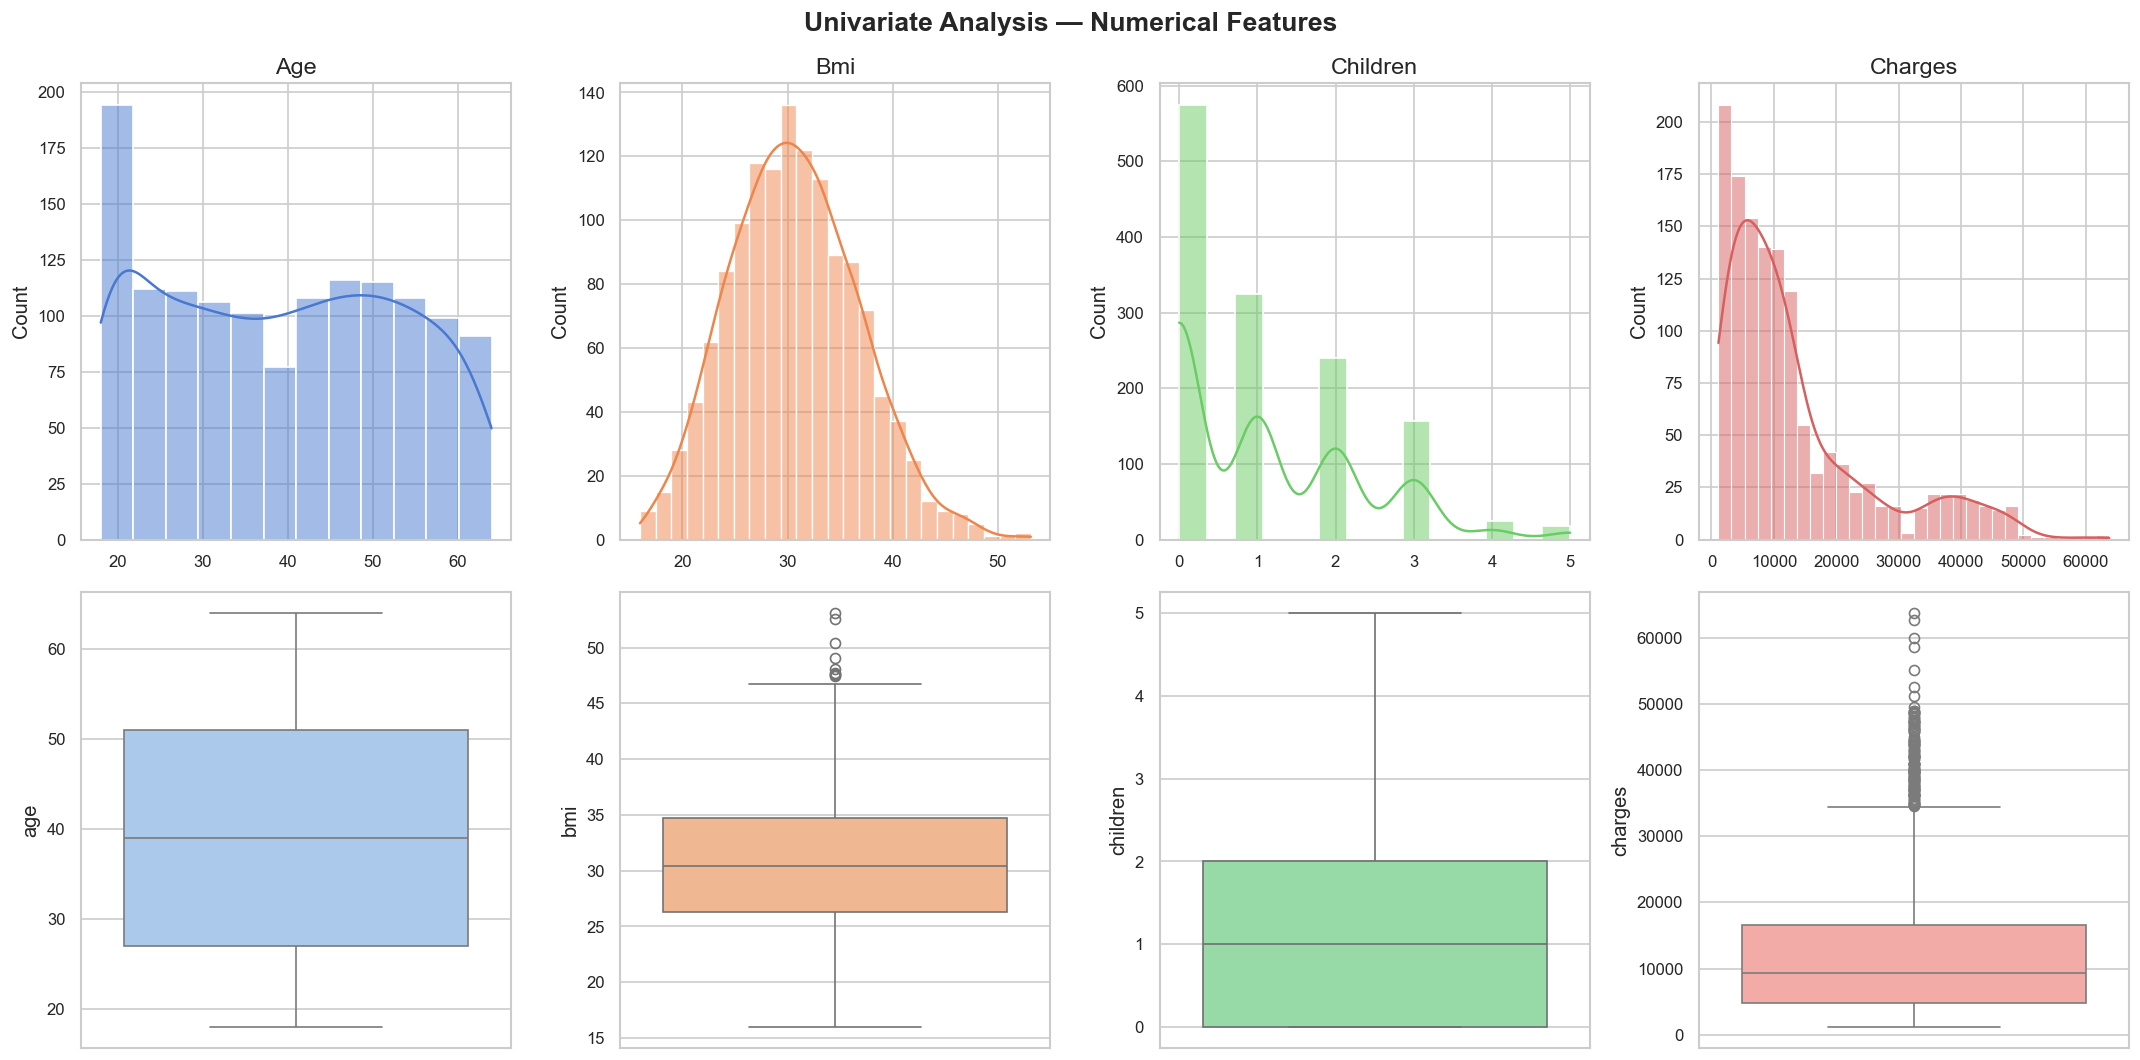

In [6]:
num_cols = ['age', 'bmi', 'children', 'charges']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Univariate Analysis — Numerical Features', fontweight='bold')

for i, col in enumerate(num_cols):
    ax_hist = axes[0, i]
    ax_box  = axes[1, i]

    # Histogram + KDE
    sns.histplot(df[col], kde=True, ax=ax_hist, color=sns.color_palette('muted')[i])
    ax_hist.set_title(col.capitalize())
    ax_hist.set_xlabel('')

    # Box-plot
    sns.boxplot(y=df[col], ax=ax_box, color=sns.color_palette('pastel')[i])
    ax_box.set_ylabel(col)

plt.tight_layout()
plt.show()

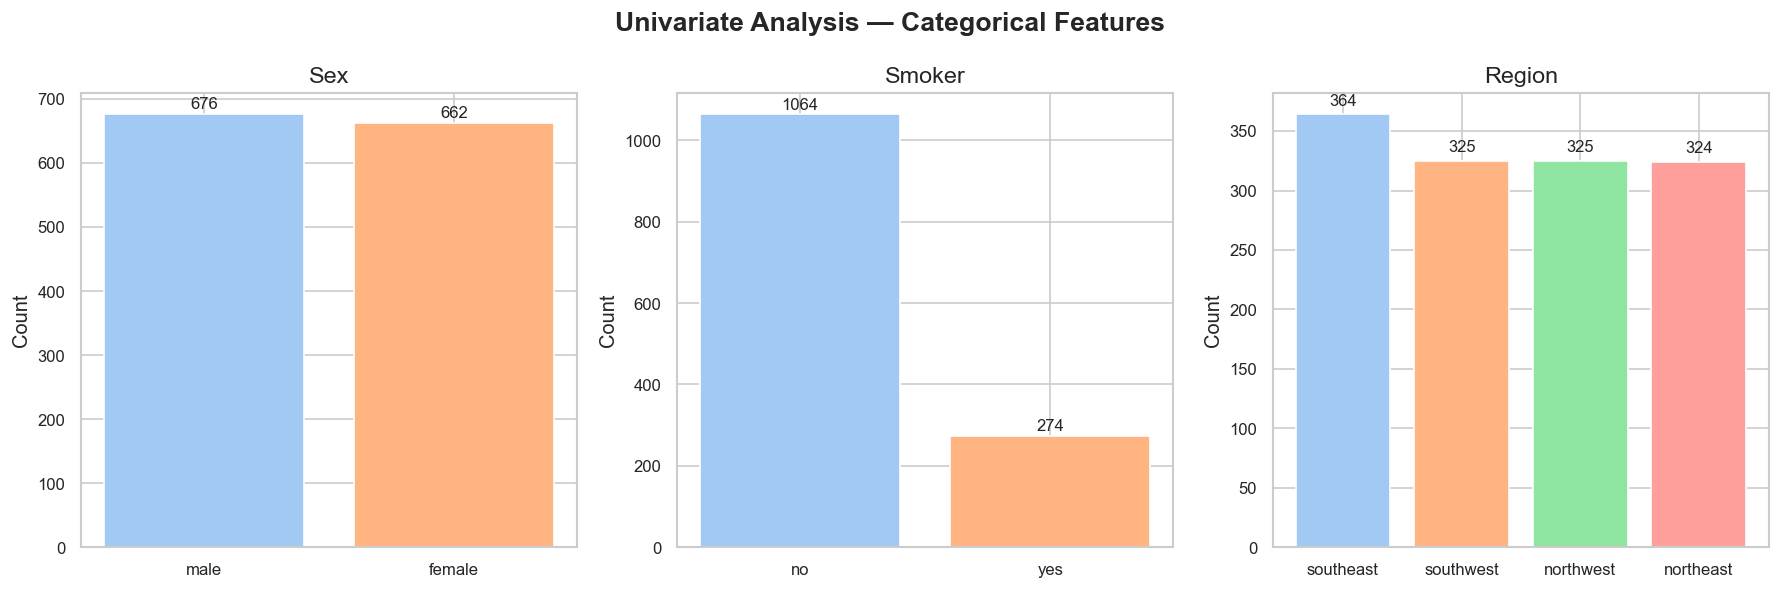

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Univariate Analysis — Categorical Features', fontweight='bold')

for ax, col in zip(axes, cat_cols):
    counts = df[col].value_counts()
    bars = ax.bar(counts.index, counts.values,
                  color=sns.color_palette('pastel', len(counts)))
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 5,
                f'{int(bar.get_height())}',
                ha='center', va='bottom', fontsize=10)
    ax.set_title(col.capitalize())
    ax.set_ylabel('Count')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

In [8]:
print('=== Skewness & Kurtosis ===')
sk_kurt = pd.DataFrame({
    'Skewness': df[num_cols].skew().round(3),
    'Kurtosis': df[num_cols].kurt().round(3)
})
display(sk_kurt)

=== Skewness & Kurtosis ===


,Skewness,Kurtosis
age,0.056,-1.245
bmi,0.284,-0.051
children,0.938,0.202
charges,1.516,1.606


## 5. Bivariate Analysis

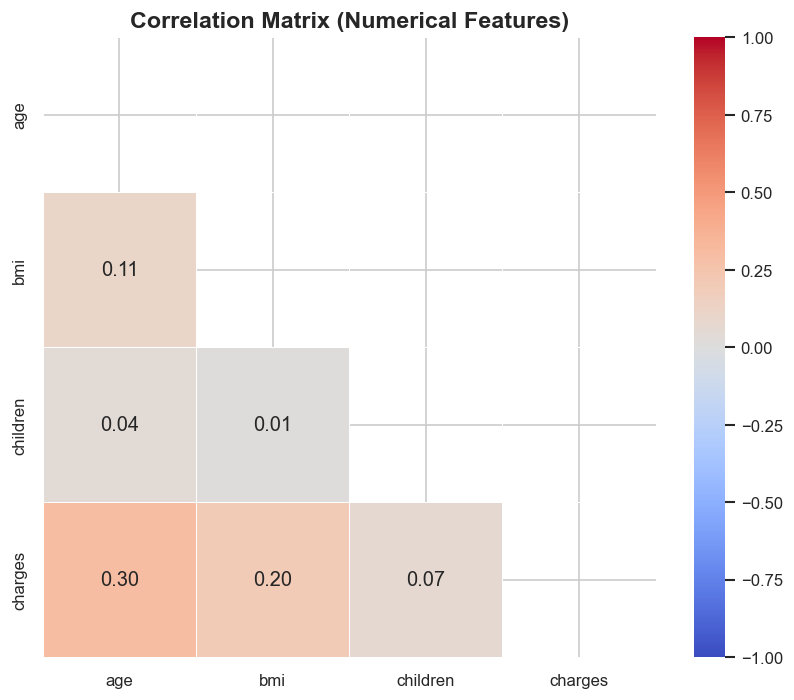

In [9]:
num_df = df[num_cols]
corr = num_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix (Numerical Features)', fontweight='bold')
plt.tight_layout()
plt.show()

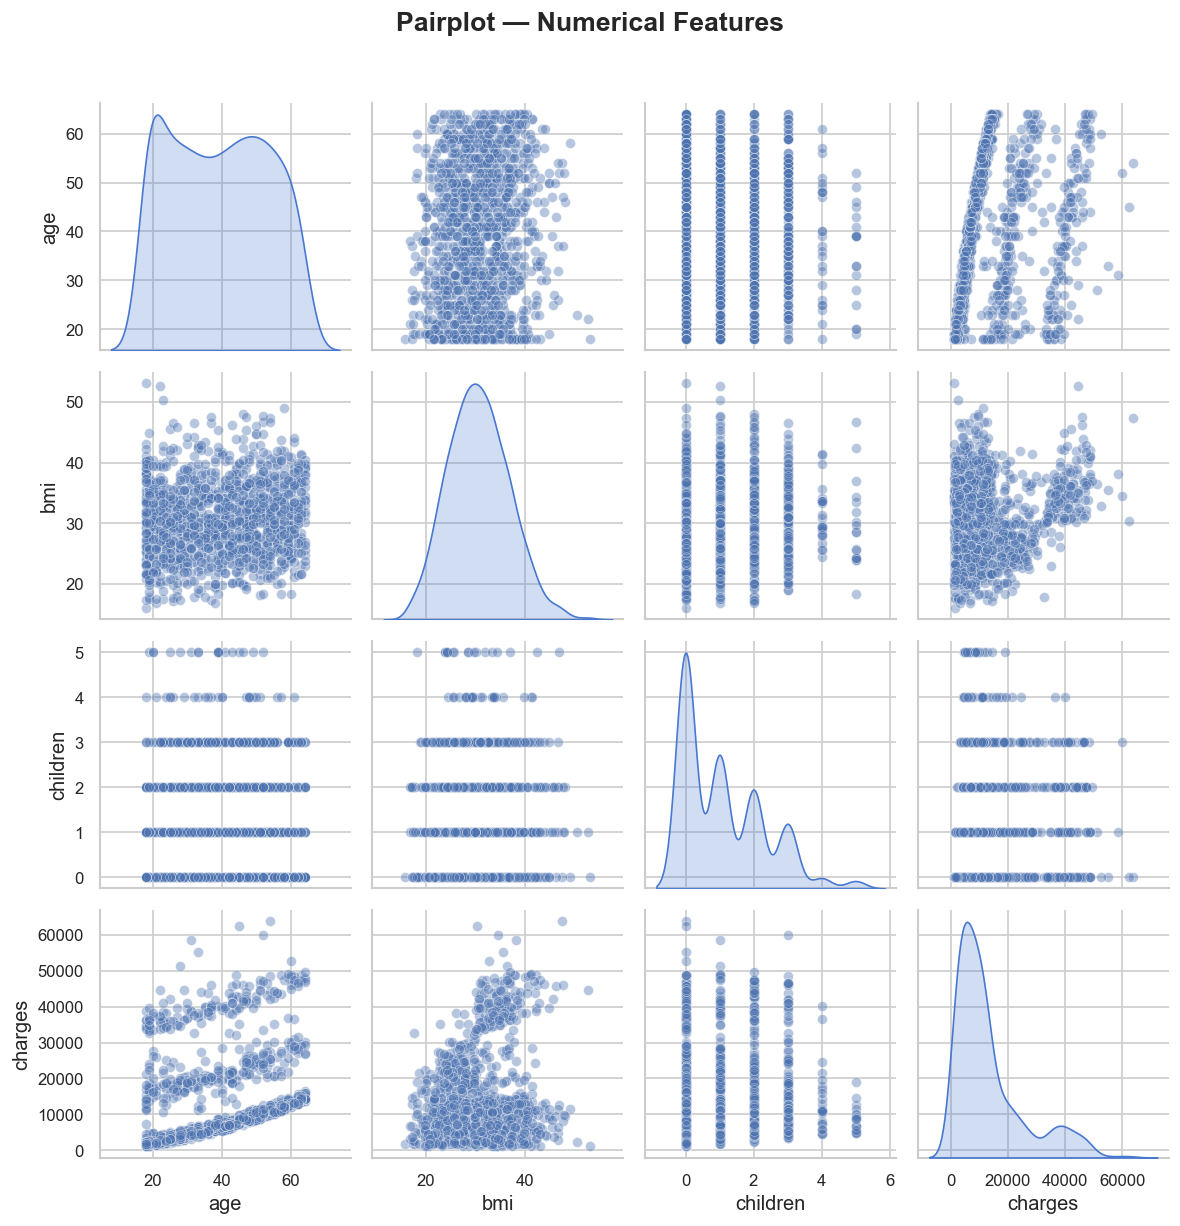

In [10]:
g = sns.pairplot(df[num_cols], diag_kind='kde', plot_kws={'alpha': 0.4, 'color': '#4C72B0'})
g.figure.suptitle('Pairplot — Numerical Features', y=1.02, fontweight='bold')
plt.tight_layout()
plt.show()

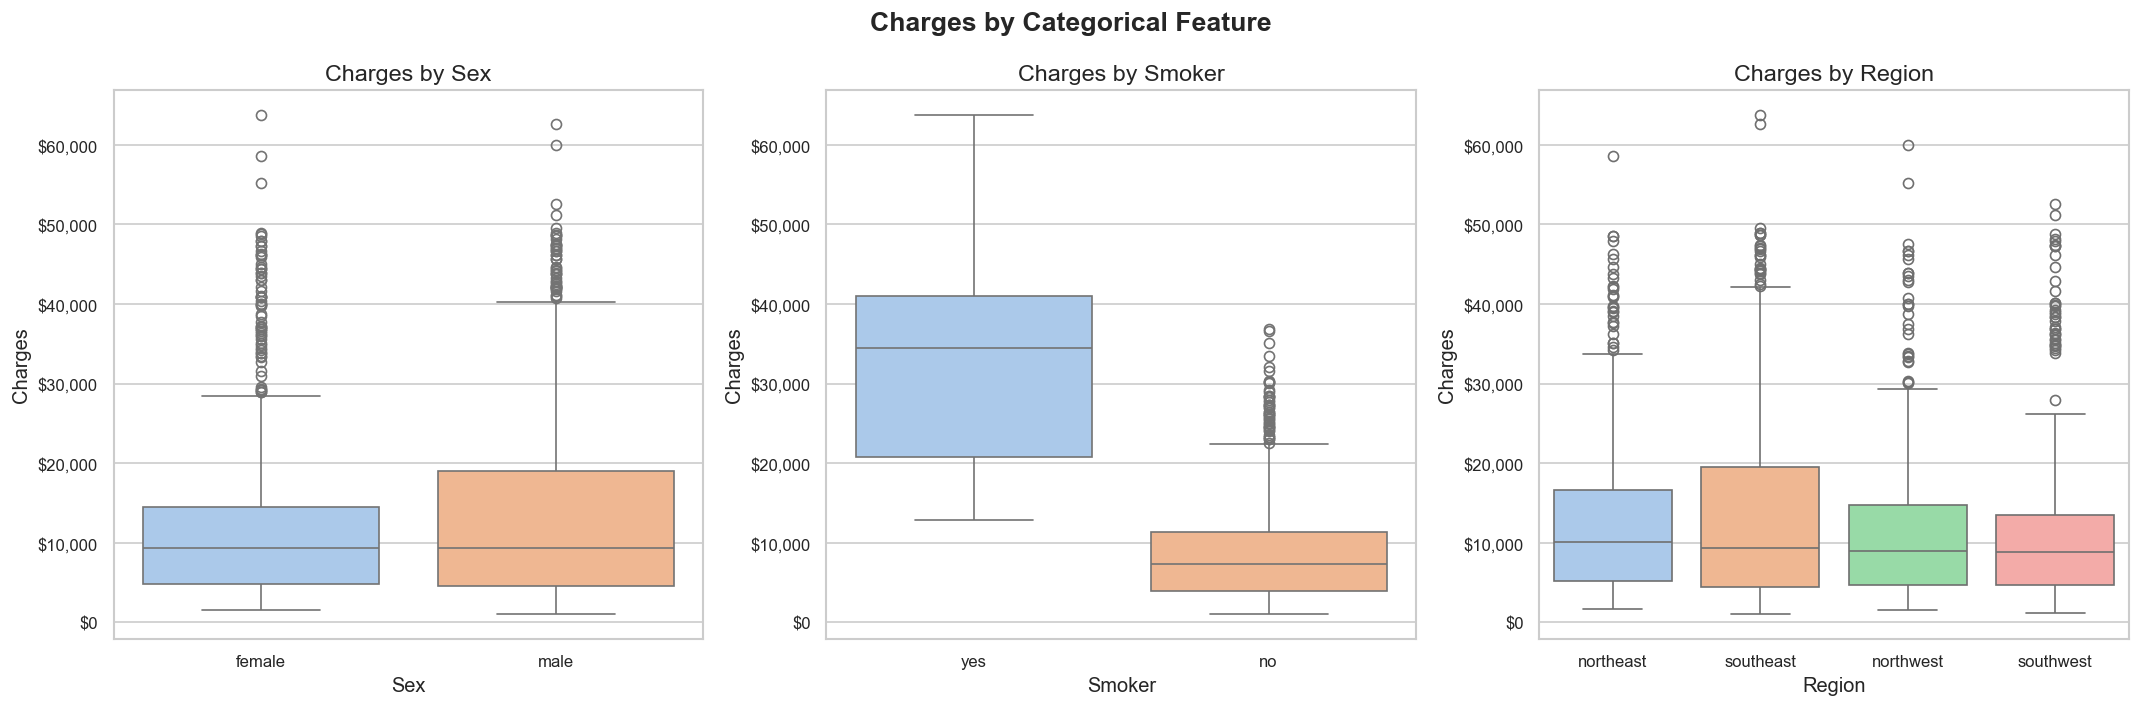

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Charges by Categorical Feature', fontweight='bold')

for ax, col in zip(axes, cat_cols):
    order = df.groupby(col)['charges'].median().sort_values(ascending=False).index
    sns.boxplot(data=df, x=col, y='charges', order=order,
                palette='pastel', ax=ax)
    ax.set_title(f'Charges by {col.capitalize()}')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Charges')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

In [12]:
print('=== Mean Charges by Categorical Feature ===')
for col in cat_cols:
    print(f'\n{col.upper()}')
    print(df.groupby(col)['charges'].agg(['mean', 'median', 'std']).round(2))

=== Mean Charges by Categorical Feature ===

SEX
            mean   median       std
sex                                
female  12569.58  9412.96  11128.70
male    13956.75  9369.62  12971.03

SMOKER
            mean    median       std
smoker                              
no       8434.27   7345.41   5993.78
yes     32050.23  34456.35  11541.55

REGION
               mean    median       std
region                                 
northeast  13406.38  10057.65  11255.80
northwest  12417.58   8965.80  11072.28
southeast  14735.41   9294.13  13971.10
southwest  12346.94   8798.59  11557.18


## 6. Multivariate Analysis

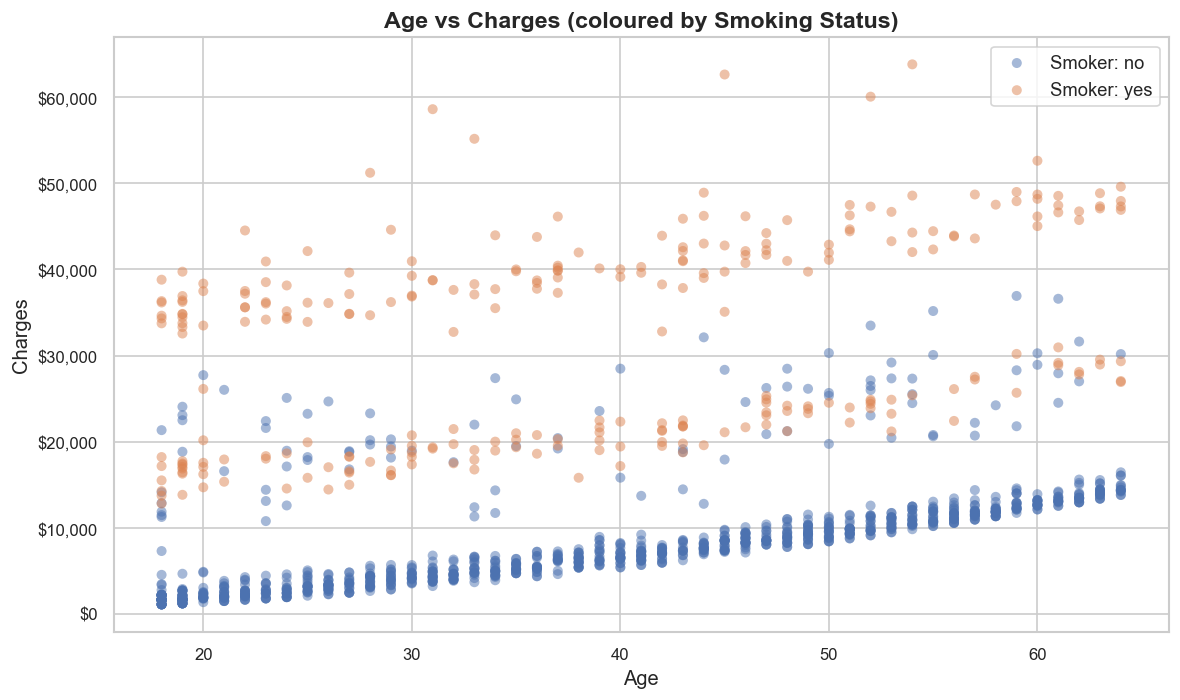

In [13]:
fig, ax = plt.subplots(figsize=(10, 6))
for smoker_status, grp in df.groupby('smoker'):
    ax.scatter(grp['age'], grp['charges'],
               label=f"Smoker: {smoker_status}",
               color=PALETTE[smoker_status], alpha=0.5, edgecolors='none')
ax.set_title('Age vs Charges (coloured by Smoking Status)', fontweight='bold')
ax.set_xlabel('Age')
ax.set_ylabel('Charges')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

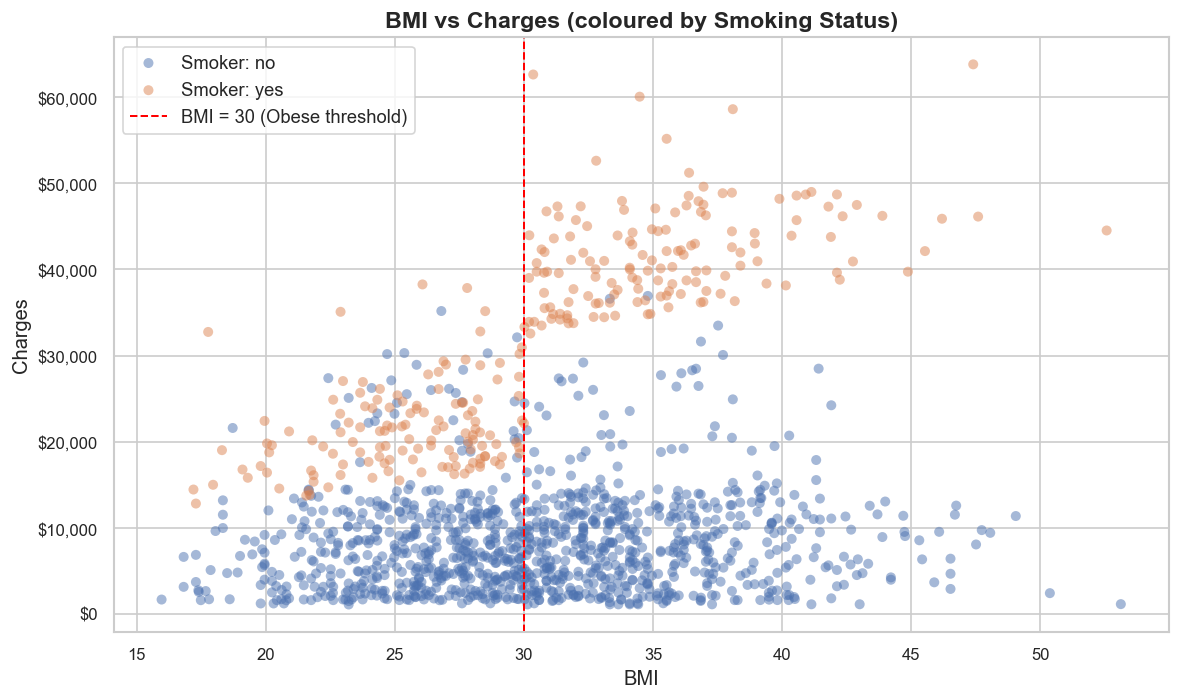

In [14]:
fig, ax = plt.subplots(figsize=(10, 6))
for smoker_status, grp in df.groupby('smoker'):
    ax.scatter(grp['bmi'], grp['charges'],
               label=f"Smoker: {smoker_status}",
               color=PALETTE[smoker_status], alpha=0.5, edgecolors='none')
ax.axvline(30, color='red', linestyle='--', linewidth=1.2, label='BMI = 30 (Obese threshold)')
ax.set_title('BMI vs Charges (coloured by Smoking Status)', fontweight='bold')
ax.set_xlabel('BMI')
ax.set_ylabel('Charges')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
ax.legend()
plt.tight_layout()
plt.show()

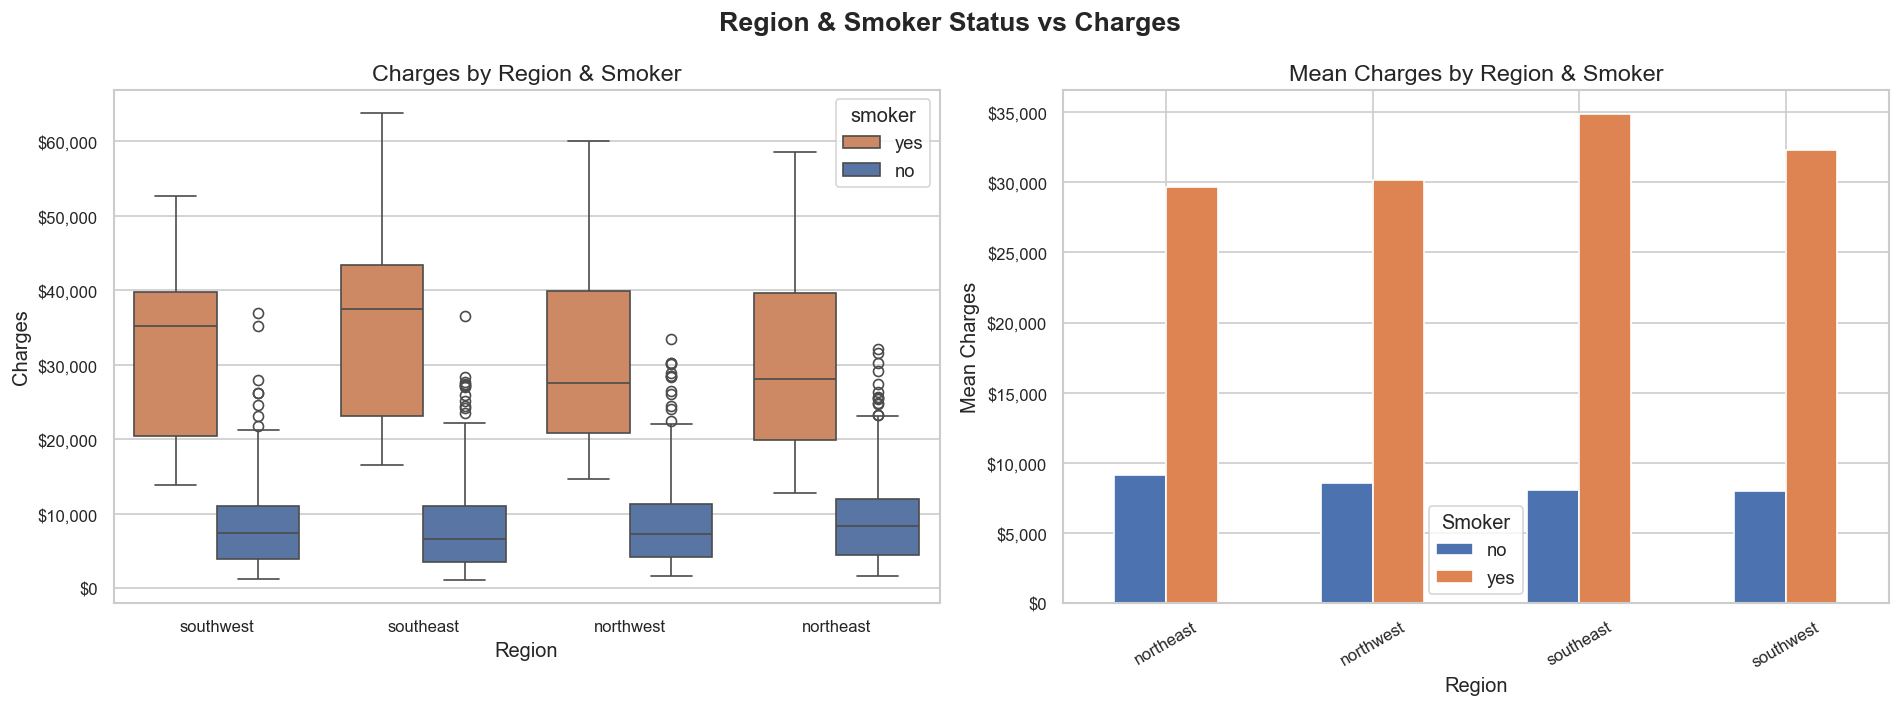

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Region & Smoker Status vs Charges', fontweight='bold')

sns.boxplot(data=df, x='region', y='charges', hue='smoker',
            palette=PALETTE, ax=axes[0])
axes[0].set_title('Charges by Region & Smoker')
axes[0].set_xlabel('Region')
axes[0].set_ylabel('Charges')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

region_smoker = df.pivot_table(values='charges', index='region',
                               columns='smoker', aggfunc='mean').round(0)
region_smoker.plot(kind='bar', ax=axes[1], color=[PALETTE['no'], PALETTE['yes']],
                   edgecolor='white')
axes[1].set_title('Mean Charges by Region & Smoker')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Mean Charges')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].tick_params(axis='x', rotation=30)
axes[1].legend(title='Smoker')

plt.tight_layout()
plt.show()

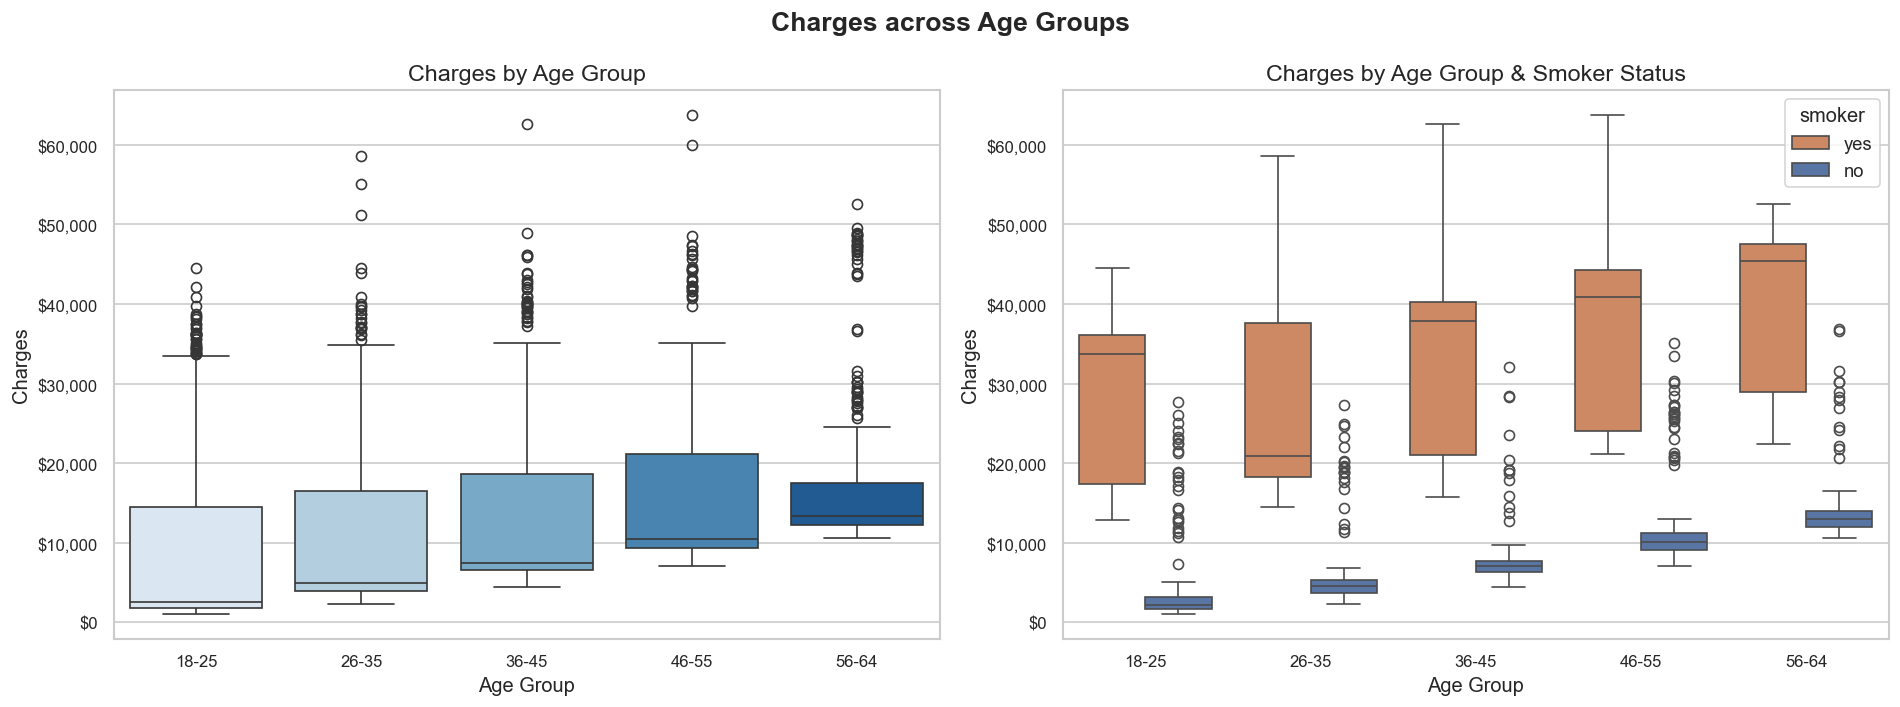

In [16]:
df['age_group'] = pd.cut(df['age'], bins=[17, 25, 35, 45, 55, 65],
                          labels=['18-25', '26-35', '36-45', '46-55', '56-64'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Charges across Age Groups', fontweight='bold')

sns.boxplot(data=df, x='age_group', y='charges', palette='Blues', ax=axes[0])
axes[0].set_title('Charges by Age Group')
axes[0].set_xlabel('Age Group')
axes[0].set_ylabel('Charges')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.boxplot(data=df, x='age_group', y='charges', hue='smoker',
            palette=PALETTE, ax=axes[1])
axes[1].set_title('Charges by Age Group & Smoker Status')
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Charges')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

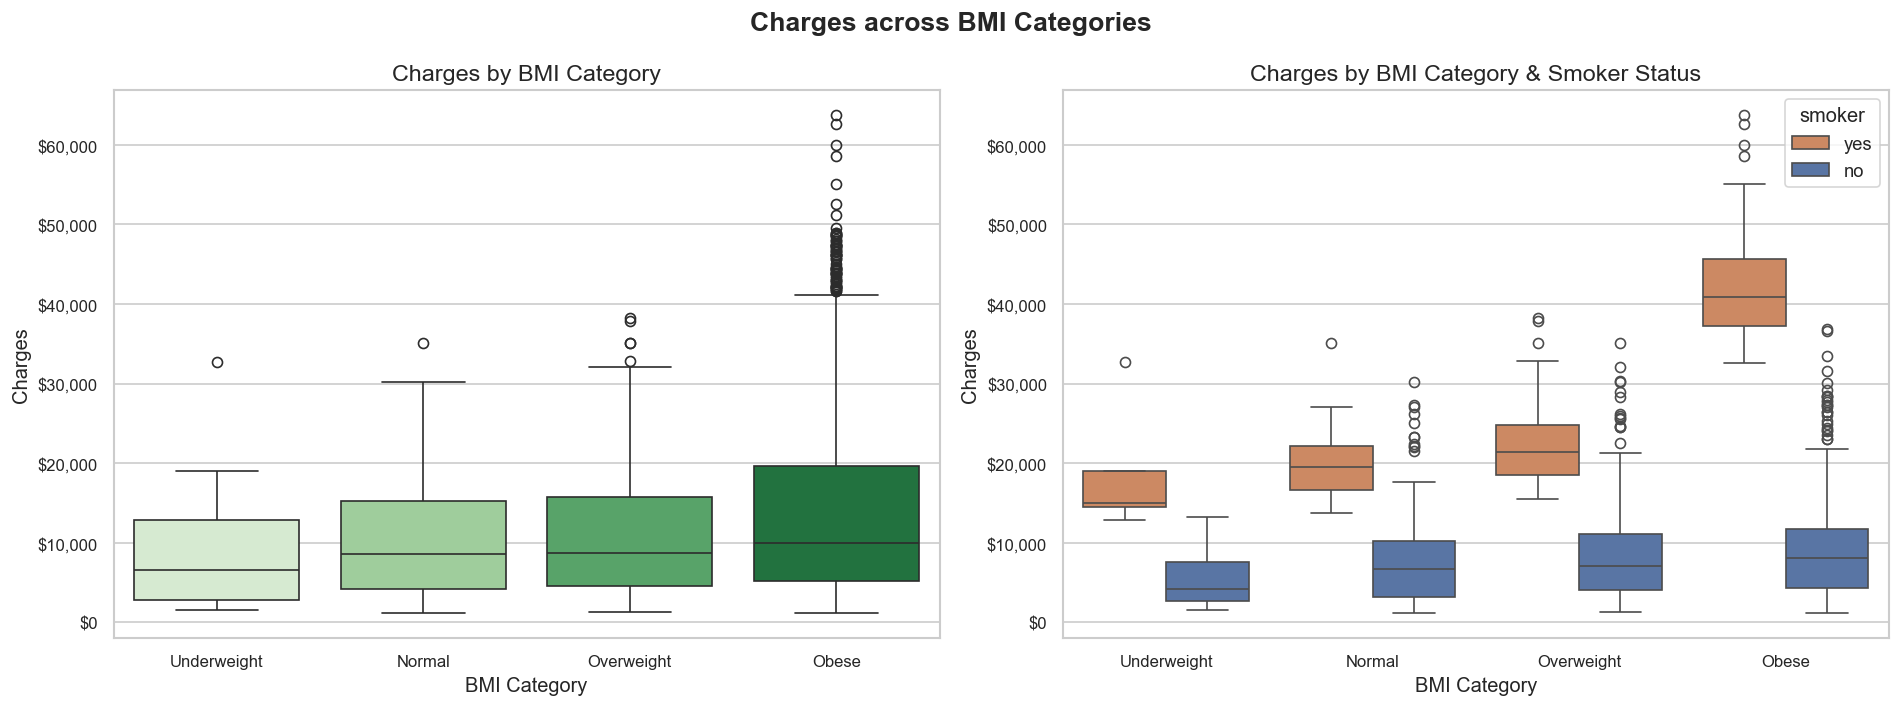

In [17]:
df['bmi_category'] = pd.cut(df['bmi'],
                             bins=[0, 18.5, 25, 30, 100],
                             labels=['Underweight', 'Normal', 'Overweight', 'Obese'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Charges across BMI Categories', fontweight='bold')

order_bmi = ['Underweight', 'Normal', 'Overweight', 'Obese']
sns.boxplot(data=df, x='bmi_category', y='charges', order=order_bmi,
            palette='Greens', ax=axes[0])
axes[0].set_title('Charges by BMI Category')
axes[0].set_xlabel('BMI Category')
axes[0].set_ylabel('Charges')
axes[0].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

sns.boxplot(data=df, x='bmi_category', y='charges', hue='smoker',
            order=order_bmi, palette=PALETTE, ax=axes[1])
axes[1].set_title('Charges by BMI Category & Smoker Status')
axes[1].set_xlabel('BMI Category')
axes[1].set_ylabel('Charges')
axes[1].yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

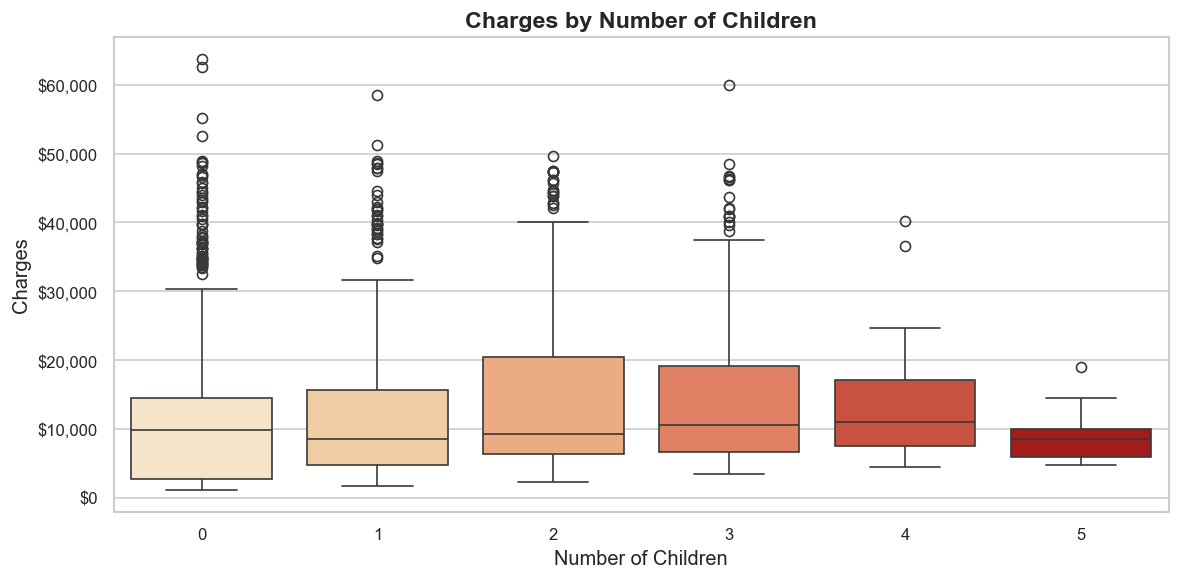

In [18]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=df, x='children', y='charges', palette='OrRd', ax=ax)
ax.set_title('Charges by Number of Children', fontweight='bold')
ax.set_xlabel('Number of Children')
ax.set_ylabel('Charges')
ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

## 7. Feature Relationships with Target (Charges)

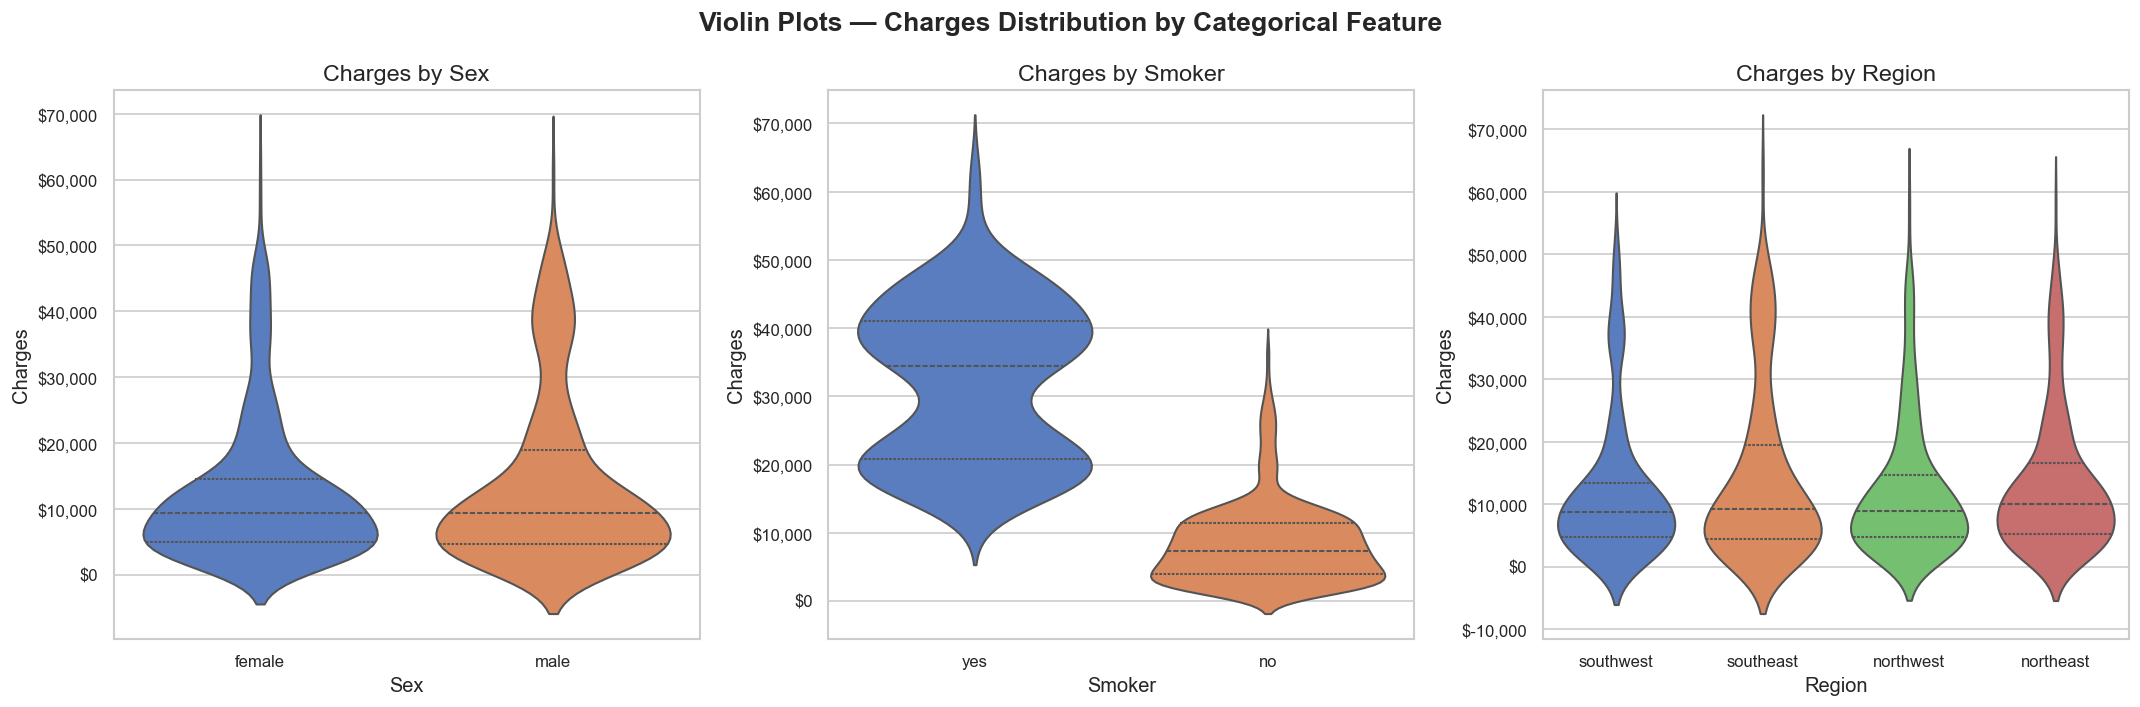

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Violin Plots — Charges Distribution by Categorical Feature', fontweight='bold')

for ax, col in zip(axes, cat_cols):
    sns.violinplot(data=df, x=col, y='charges', palette='muted', ax=ax, inner='quartile')
    ax.set_title(f'Charges by {col.capitalize()}')
    ax.set_xlabel(col.capitalize())
    ax.set_ylabel('Charges')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

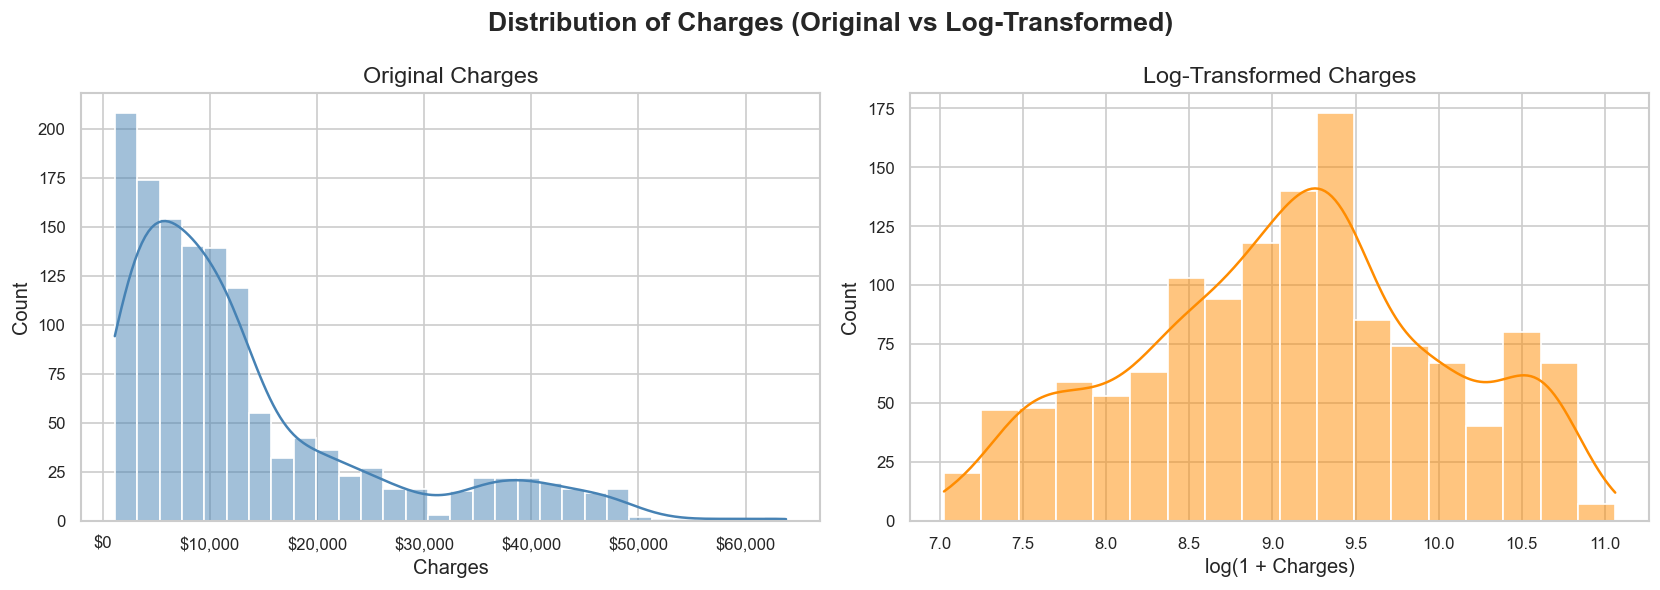

Shapiro-Wilk test on Charges (sample n=200): stat=0.8102, p=7.1861e-15
→ Charges are NOT normally distributed


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Charges (Original vs Log-Transformed)', fontweight='bold')

# Original
sns.histplot(df['charges'], kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Original Charges')
axes[0].set_xlabel('Charges')
axes[0].xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Log-transformed
sns.histplot(np.log1p(df['charges']), kde=True, ax=axes[1], color='darkorange')
axes[1].set_title('Log-Transformed Charges')
axes[1].set_xlabel('log(1 + Charges)')

plt.tight_layout()
plt.show()

stat, p = stats.shapiro(df['charges'].sample(200, random_state=42))
print(f'Shapiro-Wilk test on Charges (sample n=200): stat={stat:.4f}, p={p:.4e}')
print('→ Charges are NOT normally distributed' if p < 0.05 else '→ Charges appear normally distributed')

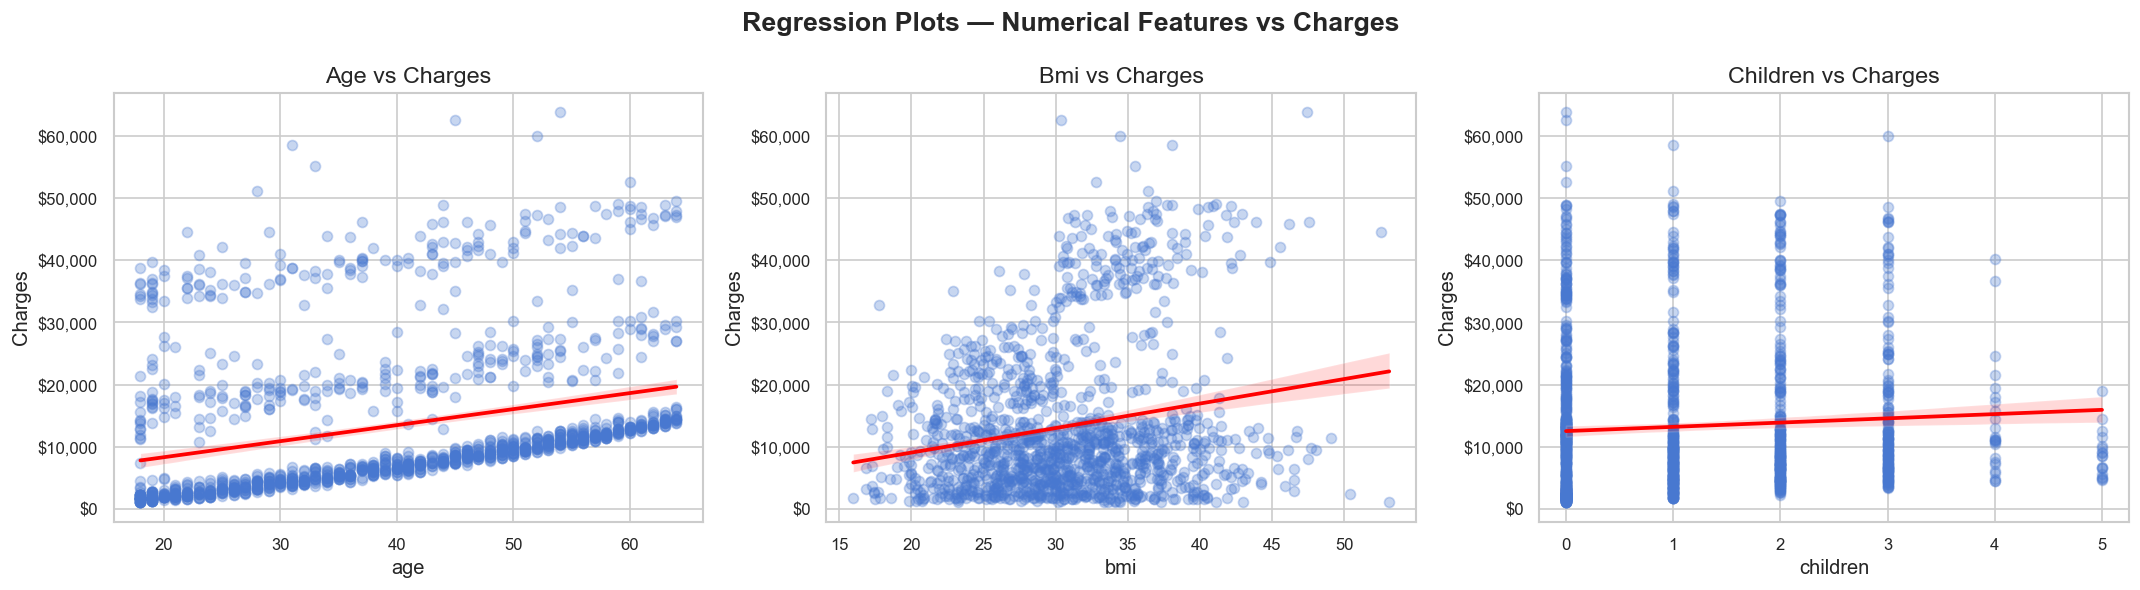

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Regression Plots — Numerical Features vs Charges', fontweight='bold')

for ax, col in zip(axes, ['age', 'bmi', 'children']):
    sns.regplot(data=df, x=col, y='charges', ax=ax,
                scatter_kws={'alpha': 0.3}, line_kws={'color': 'red'})
    ax.set_title(f'{col.capitalize()} vs Charges')
    ax.set_ylabel('Charges')
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.show()

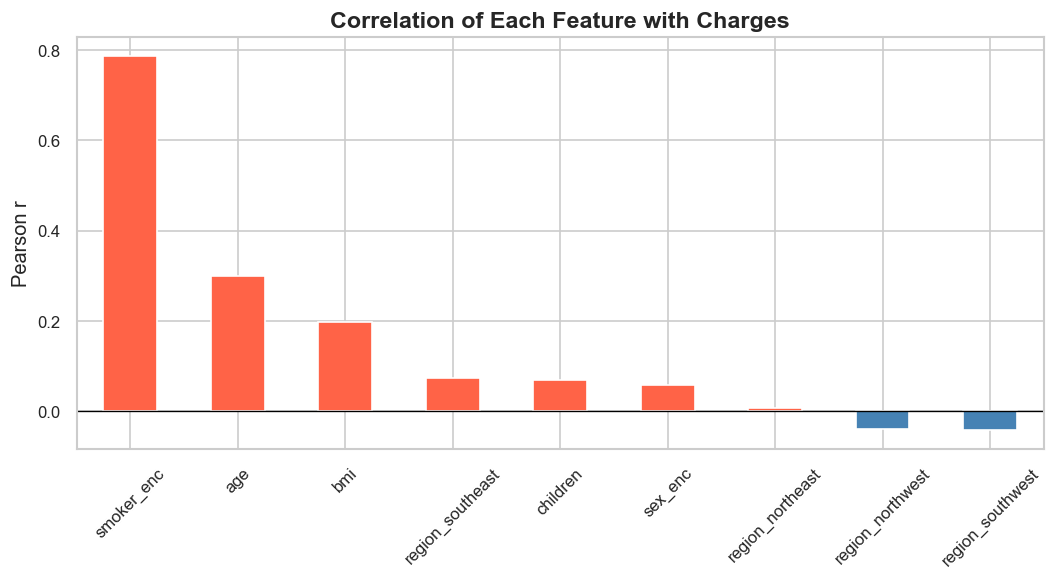

smoker_enc          0.787
age                 0.299
bmi                 0.198
region_southeast    0.074
children            0.068
sex_enc             0.057
region_northeast    0.006
region_northwest   -0.040
region_southwest   -0.043
Name: charges, dtype: float64


In [22]:
# Encode categorical variables and compute correlations with charges
df_enc = df.copy()
df_enc['sex_enc']    = (df_enc['sex'] == 'male').astype(int)
df_enc['smoker_enc'] = (df_enc['smoker'] == 'yes').astype(int)
df_enc = pd.get_dummies(df_enc, columns=['region'], drop_first=False)
drop_cols = ['sex', 'smoker', 'age_group', 'bmi_category']
df_enc = df_enc.drop(columns=[c for c in drop_cols if c in df_enc.columns])

corr_with_charges = df_enc.corr()['charges'].drop('charges').sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['tomato' if v >= 0 else 'steelblue' for v in corr_with_charges]
corr_with_charges.plot(kind='bar', color=colors, edgecolor='white', ax=ax)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Correlation of Each Feature with Charges', fontweight='bold')
ax.set_ylabel('Pearson r')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()
print(corr_with_charges.round(3))

## 8. Outlier Detection

In [23]:
def iqr_outliers(series):
    Q1  = series.quantile(0.25)
    Q3  = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    mask  = (series < lower) | (series > upper)
    return mask.sum(), lower, upper

print(f"{'Feature':<12} {'# Outliers':>10} {'Lower Fence':>14} {'Upper Fence':>14}")
print('-' * 54)
for col in num_cols:
    n, lo, hi = iqr_outliers(df[col])
    print(f"{col:<12} {n:>10} {lo:>14.2f} {hi:>14.2f}")

Feature      # Outliers    Lower Fence    Upper Fence
------------------------------------------------------
age                   0          -9.00          87.00
bmi                   9          13.70          47.29
children              0          -3.00           5.00
charges             139      -13109.15       34489.35


In [24]:
print('Z-score outliers (|z| > 3):')
for col in num_cols:
    z = np.abs(stats.zscore(df[col]))
    print(f"  {col}: {(z > 3).sum()} outlier(s)")

Z-score outliers (|z| > 3):
  age: 0 outlier(s)
  bmi: 4 outlier(s)
  children: 18 outlier(s)
  charges: 7 outlier(s)


## 9. Statistical Summary & Key Insights

In [25]:
from scipy.stats import f_oneway, ttest_ind, mannwhitneyu, kruskal

# ── Smoker vs. Non-Smoker charges (Mann-Whitney U, since charges are skewed) ──
smokers     = df.loc[df['smoker'] == 'yes', 'charges']
non_smokers = df.loc[df['smoker'] == 'no',  'charges']
stat, p = mannwhitneyu(smokers, non_smokers, alternative='two-sided')
print('=== Mann-Whitney U: Smoker vs Non-Smoker Charges ===')
print(f'Statistic={stat:.1f}, p-value={p:.4e}')
print('→ Significant difference' if p < 0.05 else '→ No significant difference')

print(f'\nMean Charges — Smokers: ${smokers.mean():,.2f} | Non-Smokers: ${non_smokers.mean():,.2f}')
print(f'Ratio: {smokers.mean() / non_smokers.mean():.1f}x higher for smokers\n')

# ── Region (Kruskal-Wallis) ────────────────────────────────────────────────
groups = [grp['charges'].values for _, grp in df.groupby('region')]
stat, p = kruskal(*groups)
print('=== Kruskal-Wallis: Charges across Regions ===')
print(f'Statistic={stat:.3f}, p-value={p:.4f}')
print('→ Significant difference across regions' if p < 0.05 else '→ No significant difference')

# ── Sex ────────────────────────────────────────────────────────────────────
males   = df.loc[df['sex'] == 'male',   'charges']
females = df.loc[df['sex'] == 'female', 'charges']
stat, p = mannwhitneyu(males, females, alternative='two-sided')
print('\n=== Mann-Whitney U: Male vs Female Charges ===')
print(f'Statistic={stat:.1f}, p-value={p:.4f}')
print('→ Significant difference' if p < 0.05 else '→ No significant difference')
print(f'Mean Charges — Male: ${males.mean():,.2f} | Female: ${females.mean():,.2f}')

=== Mann-Whitney U: Smoker vs Non-Smoker Charges ===
Statistic=284133.0, p-value=5.2702e-130
→ Significant difference

Mean Charges — Smokers: $32,050.23 | Non-Smokers: $8,434.27
Ratio: 3.8x higher for smokers

=== Kruskal-Wallis: Charges across Regions ===
Statistic=4.734, p-value=0.1923
→ No significant difference

=== Mann-Whitney U: Male vs Female Charges ===
Statistic=226208.0, p-value=0.7287
→ No significant difference
Mean Charges — Male: $13,956.75 | Female: $12,569.58


In [26]:
print('=== Mean Charges — Smoker + BMI Category ===')
pivot = df.pivot_table(values='charges', index='bmi_category',
                        columns='smoker', aggfunc='mean').round(0)
display(pivot)

print('\n=== Mean Charges — Age Group + Smoker ===')
pivot2 = df.pivot_table(values='charges', index='age_group',
                         columns='smoker', aggfunc='mean').round(0)
display(pivot2)

=== Mean Charges — Smoker + BMI Category ===


smoker,no,yes
bmi_category,,
Underweight,5485.0,18810.0
Normal,7735.0,19942.0
Overweight,8226.0,22491.0
Obese,8853.0,41693.0



=== Mean Charges — Age Group + Smoker ===


smoker,no,yes
age_group,,
18-25,4004.0,27934.0
26-35,5797.0,28282.0
36-45,7823.0,32365.0
46-55,11693.0,35145.0
56-64,14088.0,39513.0


In [27]:
print("""
╔══════════════════════════════════ KEY INSIGHTS ═══════════════════════════════╗

  1. SMOKING is by far the strongest predictor of insurance charges.
     Smokers pay ~4× more on average than non-smokers.

  2. AGE has a moderate positive correlation with charges (~0.30).
     Older policyholders tend to pay more, but the relationship is
     especially steep for smokers.

  3. BMI ≥ 30 (Obese) combined with smoking dramatically inflates charges —
     the highest-cost segment in the dataset.

  4. REGION has minimal impact on charges (no statistically significant
     difference after controlling for other factors).

  5. SEX shows a small but not statistically significant difference in
     charges (males slightly higher on average).

  6. NUMBER OF CHILDREN has very little impact on charges.

  7. CHARGES are right-skewed; a log transformation improves normality,
     which is useful for linear regression models.

  8. OUTLIERS are present mainly in 'charges' — likely high-cost smokers
     or elderly individuals with obesity.

  Priority features for modelling: smoker > age > bmi > children > region > sex

╚═══════════════════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════ KEY INSIGHTS ═══════════════════════════════╗

  1. SMOKING is by far the strongest predictor of insurance charges.
     Smokers pay ~4× more on average than non-smokers.

  2. AGE has a moderate positive correlation with charges (~0.30).
     Older policyholders tend to pay more, but the relationship is
     especially steep for smokers.

  3. BMI ≥ 30 (Obese) combined with smoking dramatically inflates charges —
     the highest-cost segment in the dataset.

  4. REGION has minimal impact on charges (no statistically significant
     difference after controlling for other factors).

  5. SEX shows a small but not statistically significant difference in
     charges (males slightly higher on average).

  6. NUMBER OF CHILDREN has very little impact on charges.

  7. CHARGES are right-skewed; a log transformation improves normality,
     which is useful for linear regression models.

  8. OUTLIERS are present mainly in 'charges' — likely high-cost s

---
## 10. Model Building
*(Code taken as-is from `Insurance.ipynb`)*

In [28]:

from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,confusion_matrix

In [29]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   age           1338 non-null   int64   
 1   sex           1338 non-null   object  
 2   bmi           1338 non-null   float64 
 3   children      1338 non-null   int64   
 4   smoker        1338 non-null   object  
 5   region        1338 non-null   object  
 6   charges       1338 non-null   float64 
 7   age_group     1338 non-null   category
 8   bmi_category  1338 non-null   category
dtypes: category(2), float64(2), int64(2), object(3)
memory usage: 76.3+ KB


In [30]:
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [31]:
df.isnull().sum()

age             0
sex             0
bmi             0
children        0
smoker          0
region          0
charges         0
age_group       0
bmi_category    0
dtype: int64

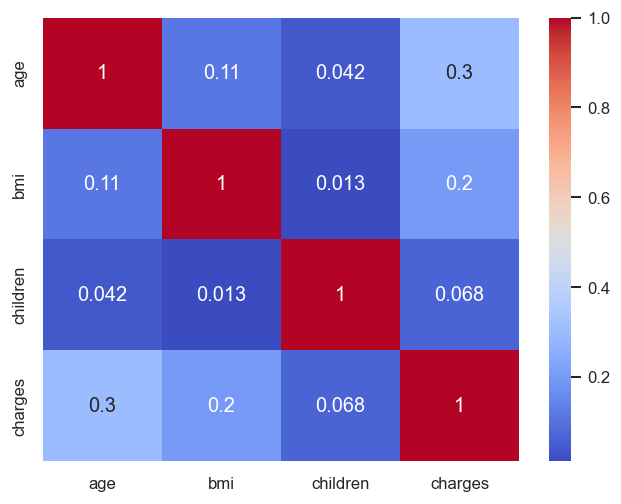

In [32]:
numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.show()

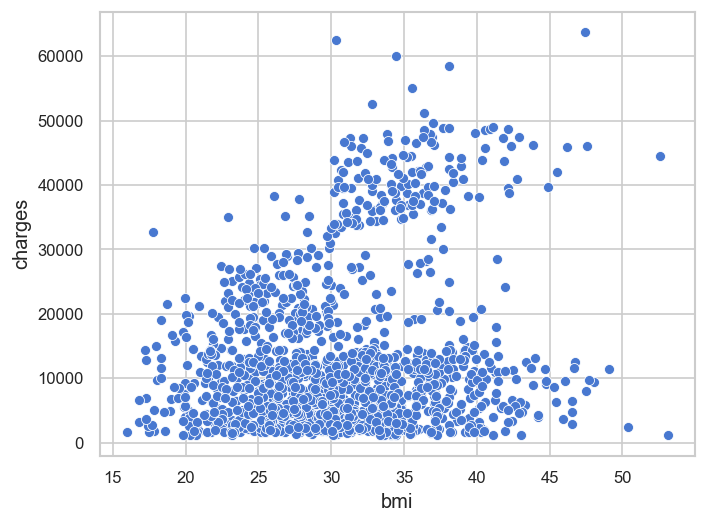

In [33]:
sns.scatterplot(x='bmi',y='charges',data=df)
plt.show()

In [34]:
df['sex'] = df['sex'].map({'male': 0, 'female': 1})
df['smoker'] = df['smoker'].map({'yes': 0, 'no': 1})

df = pd.get_dummies(df, columns=['region'], drop_first=True,dtype=int)

In [35]:
df.drop(columns=["age_group","bmi_category"],inplace=True)

In [36]:
X = df.drop(columns=["charges"])
y = df['charges']

In [37]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [38]:
model = LinearRegression()
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print(r2_score(y_test,y_pred))

0.7835929767120725


In [39]:
model_rf = RandomForestRegressor(random_state=42)
model_rf.fit(X_train,y_train)
y_pred = model_rf.predict(X_test)
print(r2_score(y_test,y_pred))

0.8643465080186038


In [40]:
param_grid = {
    "n_estimators": [100, 300],
    "max_depth": [None, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "max_features": ["sqrt"],
    "bootstrap": [True]
}

In [41]:
rf = RandomForestRegressor(random_state=42, n_jobs=-1)
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Params:", grid_search.best_params_)
print("Best Score:", grid_search.best_score_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
Best Params: {'bootstrap': True, 'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 300}
Best Score: 0.823022129850389


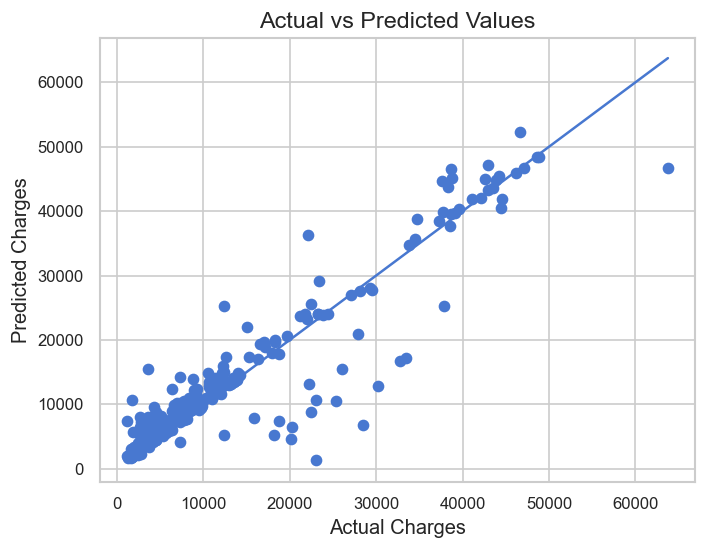

In [42]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test, y_pred)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Values")

plt.show()

---
_EDA by Antigravity. Model section taken verbatim from `Insurance.ipynb`._